# Survived 生存予測モデルの探索と視覚化

このノートブックでは、Titanic 乗客データを探索し、生存予測モデルの性能を視覚的に分析します。

## 目的

- データの傾向を視覚的に把握する
- クラス不均衡の影響を理解する
- モデルの判断基準を可視化する

## 1. 環境セットアップとデータ読み込み

In [1]:
# ライブラリのインポート
import os
import sys

# カレントディレクトリの確認
print(f"カレントディレクトリ: {os.getcwd()}")

# 親ディレクトリを sys.path に追加
sys.path.append("..")

print(f"sys.path に追加: {os.path.abspath('..')}")
print(f"src ディレクトリの存在確認: {os.path.exists('../src')}")
print(f"data ディレクトリの存在確認: {os.path.exists('../data')}")

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

# matplotlibrc ファイルを読み込み（日本語フォント設定）
matplotlib.rc_file("matplotlibrc")

# スタイル設定
sns.set_style("whitegrid")
sns.set_palette("Set2")

# seaborn 設定後に再度フォント設定を適用（seaborn が設定を上書きするため）
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "BIZ UDGothic",
    "MS Gothic",
    "Yu Gothic",
    "Meiryo",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

# フォント設定の確認
print(f"\n現在のフォント設定: {plt.rcParams['font.sans-serif']}")

print("\n環境セットアップ完了")

カレントディレクトリ: C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\python\ml_tdd\notebook
sys.path に追加: C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\python\ml_tdd
src ディレクトリの存在確認: True
data ディレクトリの存在確認: True

現在のフォント設定: ['BIZ UDGothic', 'MS Gothic', 'Yu Gothic', 'Meiryo', 'DejaVu Sans']

環境セットアップ完了


In [2]:
# データの読み込み
# TDD で実装した Survived 分類器のインポート
try:
    from src.ml.survived_classifier import SurvivedClassifier
except ImportError as e:
    print(f"インポートエラー: {e}")
    print(f"\nカレントディレクトリ: {os.getcwd()}")
    print(f"sys.path: {sys.path[:3]}")
    print("\n解決方法:")
    print("1. Jupyter Lab を app/python/ml_tdd から起動してください")
    print("2. セル1を先に実行してください")
    raise

classifier = SurvivedClassifier()
X, y = classifier.load_data("../data/Survived.csv")

print(f"データ形状: X={X.shape}, y={y.shape}")
print(f"\n特徴量:\n{X.columns.tolist()}")
print(f"\nクラス分布:\n{y.value_counts()}")
print(f"\n生存率: {(y == 1).sum() / len(y) * 100:.2f}%")

データ形状: X=(891, 6), y=(891,)

特徴量:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male']

クラス分布:
Survived
0    549
1    342
Name: count, dtype: int64

生存率: 38.38%


## 2. クラス不均衡の確認

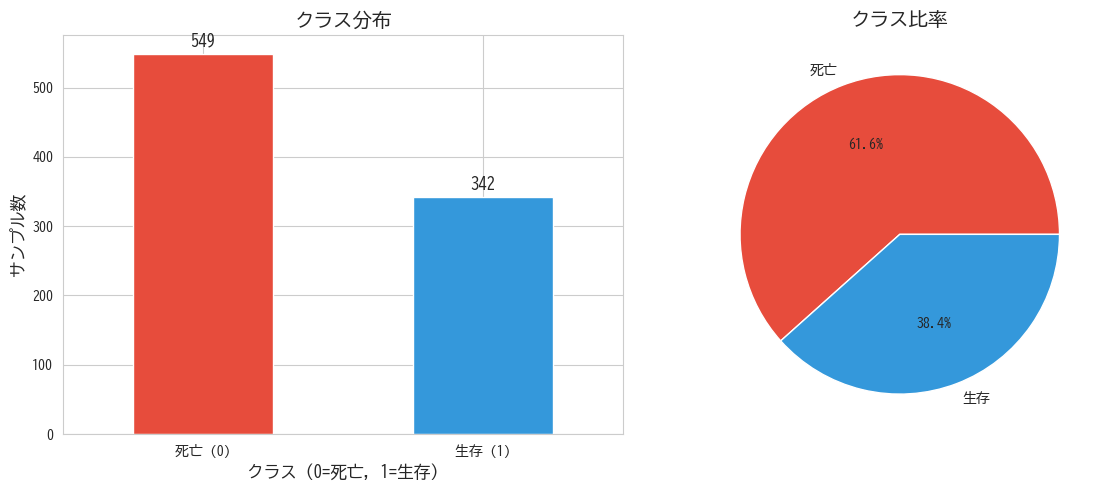


クラス不均衡率: 1.61 (死亡/生存)
→ 死亡クラスが生存クラスの 1.6 倍


In [3]:
# クラス分布の可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 棒グラフ
y.value_counts().plot(kind="bar", ax=ax1, color=["#e74c3c", "#3498db"])
ax1.set_xlabel("クラス (0=死亡, 1=生存)", fontsize=12)
ax1.set_ylabel("サンプル数", fontsize=12)
ax1.set_title("クラス分布", fontsize=14)
ax1.set_xticklabels(["死亡 (0)", "生存 (1)"], rotation=0)
for i, v in enumerate(y.value_counts()):
    ax1.text(i, v + 10, str(v), ha="center", fontsize=12)

# 円グラフ
y.value_counts().plot(
    kind="pie",
    ax=ax2,
    autopct="%1.1f%%",
    colors=["#e74c3c", "#3498db"],
    labels=["死亡", "生存"],
)
ax2.set_ylabel("")
ax2.set_title("クラス比率", fontsize=14)

plt.tight_layout()
plt.show()

# 不均衡率
imbalance_ratio = y.value_counts()[0] / y.value_counts()[1]
print(f"\nクラス不均衡率: {imbalance_ratio:.2f} (死亡/生存)")
print(f"→ 死亡クラスが生存クラスの {imbalance_ratio:.1f} 倍")

## 3. 特徴量とクラスの関係分析

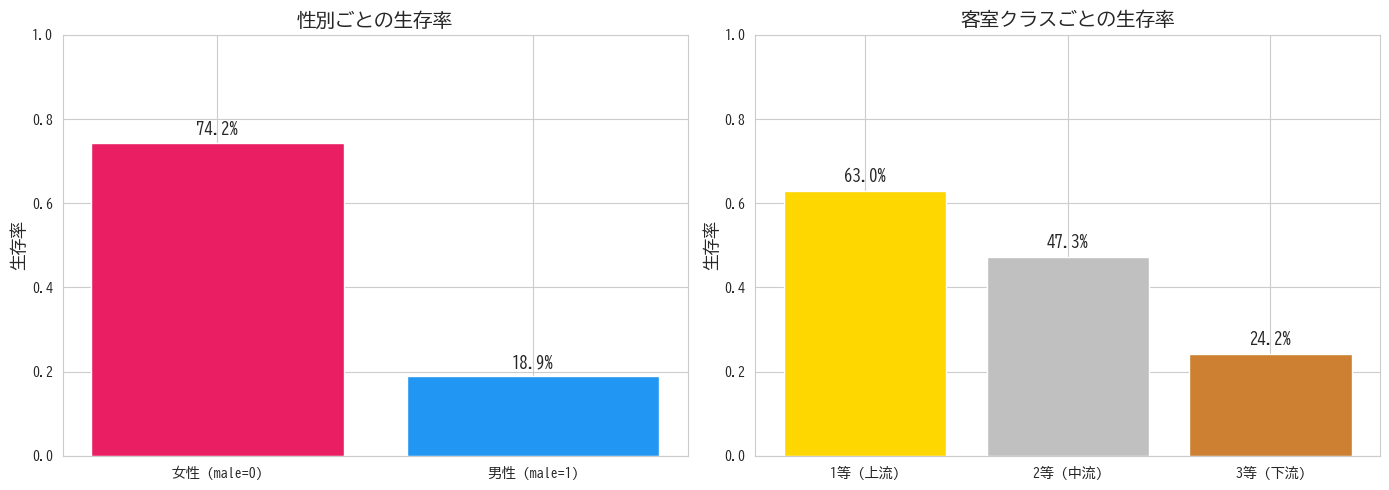

生存率の統計:
  女性: 74.2%
  男性: 18.9%
  1等客: 63.0%
  2等客: 47.3%
  3等客: 24.2%


In [4]:
# 性別と生存率の関係
df_analysis = X.copy()
df_analysis["Survived"] = y

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 性別ごとの生存率
gender_survival = df_analysis.groupby("male")["Survived"].mean()
ax = axes[0]
bars = ax.bar(
    ["女性 (male=0)", "男性 (male=1)"], gender_survival, color=["#e91e63", "#2196f3"]
)
ax.set_ylabel("生存率", fontsize=12)
ax.set_title("性別ごとの生存率", fontsize=14)
ax.set_ylim([0, 1])
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.02,
        f"{height:.1%}",
        ha="center",
        fontsize=12,
    )

# 客室クラスごとの生存率
pclass_survival = df_analysis.groupby("Pclass")["Survived"].mean()
ax = axes[1]
bars = ax.bar(
    ["1等 (上流)", "2等 (中流)", "3等 (下流)"],
    pclass_survival,
    color=["#ffd700", "#c0c0c0", "#cd7f32"],
)
ax.set_ylabel("生存率", fontsize=12)
ax.set_title("客室クラスごとの生存率", fontsize=14)
ax.set_ylim([0, 1])
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.02,
        f"{height:.1%}",
        ha="center",
        fontsize=12,
    )

plt.tight_layout()
plt.show()

print("生存率の統計:")
print(f"  女性: {gender_survival[0]:.1%}")
print(f"  男性: {gender_survival[1]:.1%}")
print(f"  1等客: {pclass_survival[1]:.1%}")
print(f"  2等客: {pclass_survival[2]:.1%}")
print(f"  3等客: {pclass_survival[3]:.1%}")

## 4. モデルの訓練と評価

In [5]:
# データ分割と訓練
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

classifier.train(X_train, y_train)
y_pred = classifier.predict(X_test)

accuracy = classifier.evaluate(X_test, y_test)
print(f"正解率: {accuracy:.4f}")

# 詳細レポート
print("\n分類レポート:")
print(classification_report(y_test, y_pred, target_names=["死亡", "生存"]))

正解率: 0.8883

分類レポート:
              precision    recall  f1-score   support

          死亡       0.92      0.90      0.91       110
          生存       0.85      0.87      0.86        69

    accuracy                           0.89       179
   macro avg       0.88      0.88      0.88       179
weighted avg       0.89      0.89      0.89       179



## 5. 混同行列の可視化

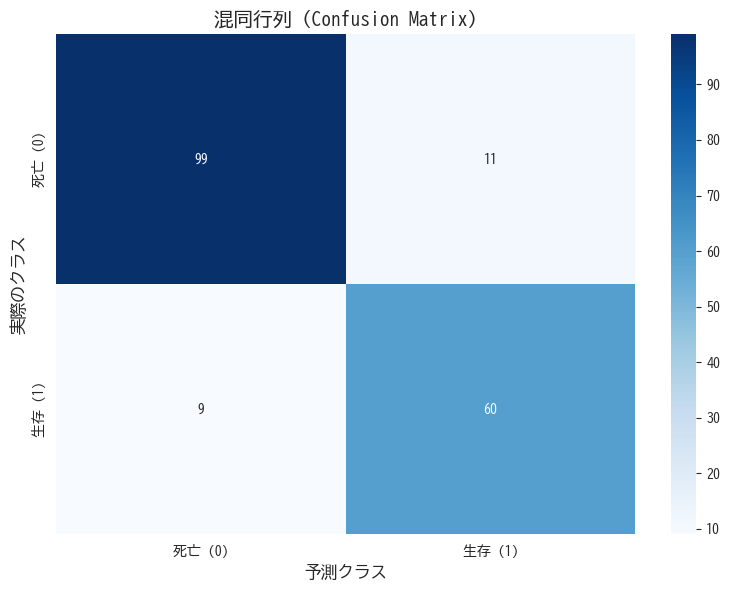


混同行列の詳細:
  真陰性 (TN): 99 - 正しく「死亡」と予測
  偽陽性 (FP): 11 - 誤って「生存」と予測
  偽陰性 (FN): 9 - 誤って「死亡」と予測
  真陽性 (TP): 60 - 正しく「生存」と予測

性能指標:
  適合率 (Precision): 0.845
  再現率 (Recall): 0.870
  F1スコア: 0.857


In [6]:
# 混同行列
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["死亡 (0)", "生存 (1)"],
    yticklabels=["死亡 (0)", "生存 (1)"],
)
plt.title("混同行列 (Confusion Matrix)", fontsize=14)
plt.ylabel("実際のクラス", fontsize=12)
plt.xlabel("予測クラス", fontsize=12)
plt.tight_layout()
plt.show()

# 混同行列の詳細分析
tn, fp, fn, tp = cm.ravel()
print("\n混同行列の詳細:")
print(f"  真陰性 (TN): {tn} - 正しく「死亡」と予測")
print(f"  偽陽性 (FP): {fp} - 誤って「生存」と予測")
print(f"  偽陰性 (FN): {fn} - 誤って「死亡」と予測")
print(f"  真陽性 (TP): {tp} - 正しく「生存」と予測")

# 各種指標
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("\n性能指標:")
print(f"  適合率 (Precision): {precision:.3f}")
print(f"  再現率 (Recall): {recall:.3f}")
print(f"  F1スコア: {f1:.3f}")

## 6. ROC 曲線と AUC

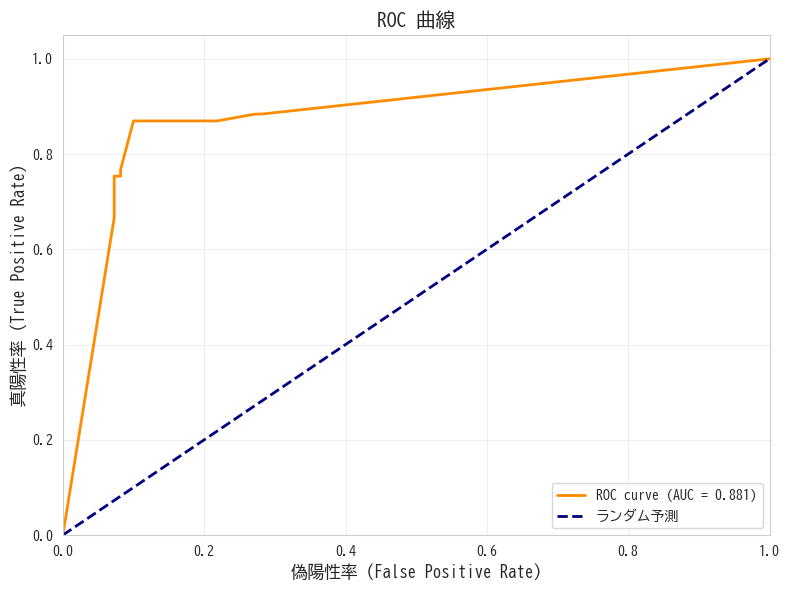

AUC スコア: 0.881
AUC の解釈:
  0.9-1.0: 優秀
  0.8-0.9: 良い
  0.7-0.8: まあまあ
  0.6-0.7: 微妙
  0.5-0.6: ほぼランダム


In [7]:
# ROC 曲線
# 予測確率を取得
y_pred_proba = classifier.model.predict_proba(X_test)[:, 1]

# ROC 曲線の計算
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# 可視化
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="ランダム予測")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("偽陽性率 (False Positive Rate)", fontsize=12)
plt.ylabel("真陽性率 (True Positive Rate)", fontsize=12)
plt.title("ROC 曲線", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC スコア: {auc_score:.3f}")
print("AUC の解釈:")
print("  0.9-1.0: 優秀")
print("  0.8-0.9: 良い")
print("  0.7-0.8: まあまあ")
print("  0.6-0.7: 微妙")
print("  0.5-0.6: ほぼランダム")

## 7. 特徴量の重要度

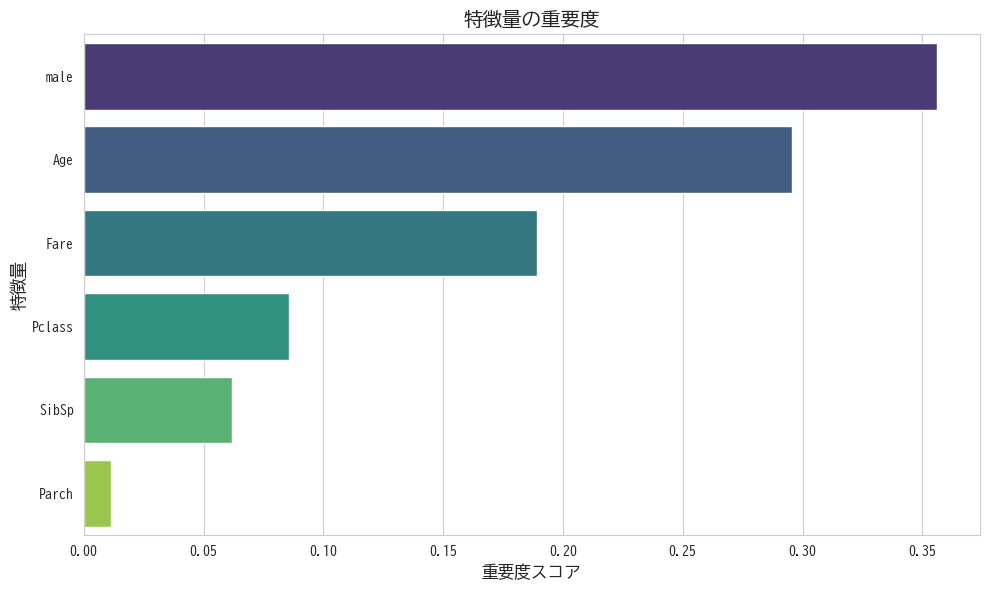


特徴量重要度ランキング:
  male      : 0.3562
  Age       : 0.2958
  Fare      : 0.1891
  Pclass    : 0.0857
  SibSp     : 0.0619
  Parch     : 0.0113


In [8]:
# 特徴量重要度の可視化
importances = classifier.model.feature_importances_
feature_importance_df = pd.DataFrame(
    {"feature": X.columns, "importance": importances}
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False,
)
plt.title("特徴量の重要度", fontsize=14)
plt.xlabel("重要度スコア", fontsize=12)
plt.ylabel("特徴量", fontsize=12)
plt.tight_layout()
plt.show()

print("\n特徴量重要度ランキング:")
for idx, row in feature_importance_df.iterrows():
    print(f"  {row['feature']:10s}: {row['importance']:.4f}")

## 8. 誤分類サンプルの分析

In [9]:
# 誤分類されたサンプルの分析
test_df = X_test.copy()
test_df["actual"] = y_test.values
test_df["predicted"] = y_pred
test_df["correct"] = test_df["actual"] == test_df["predicted"]

# 誤分類のみ抽出
misclassified = test_df[~test_df["correct"]]

print(
    f"誤分類サンプル数: {len(misclassified)} / {len(test_df)} "
    f"({len(misclassified) / len(test_df) * 100:.1f}%)"
)

# 誤分類のパターン分析
print("\n誤分類の内訳:")
false_positive = ((test_df["actual"] == 0) & (test_df["predicted"] == 1)).sum()
false_negative = ((test_df["actual"] == 1) & (test_df["predicted"] == 0)).sum()
print(f"  偽陽性 (死亡→生存と誤予測): {false_positive}")
print(f"  偽陰性 (生存→死亡と誤予測): {false_negative}")

# 誤分類されやすい特徴の分析
print("\n誤分類サンプルの平均:")
print(misclassified[["Pclass", "Age", "SibSp", "Parch", "Fare", "male"]].mean())
print("\n正しく分類されたサンプルの平均:")
print(
    test_df[test_df["correct"]][
        ["Pclass", "Age", "SibSp", "Parch", "Fare", "male"]
    ].mean()
)

誤分類サンプル数: 20 / 179 (11.2%)

誤分類の内訳:
  偽陽性 (死亡→生存と誤予測): 11
  偽陰性 (生存→死亡と誤予測): 9

誤分類サンプルの平均:
Pclass     2.35000
Age       29.10000
SibSp      0.35000
Parch      0.30000
Fare      30.96854
male       0.55000
dtype: float64

正しく分類されたサンプルの平均:
Pclass     2.264151
Age       29.254214
SibSp      0.515723
Parch      0.345912
Fare      33.887787
male       0.635220
dtype: float64


## 9. 決定木の可視化

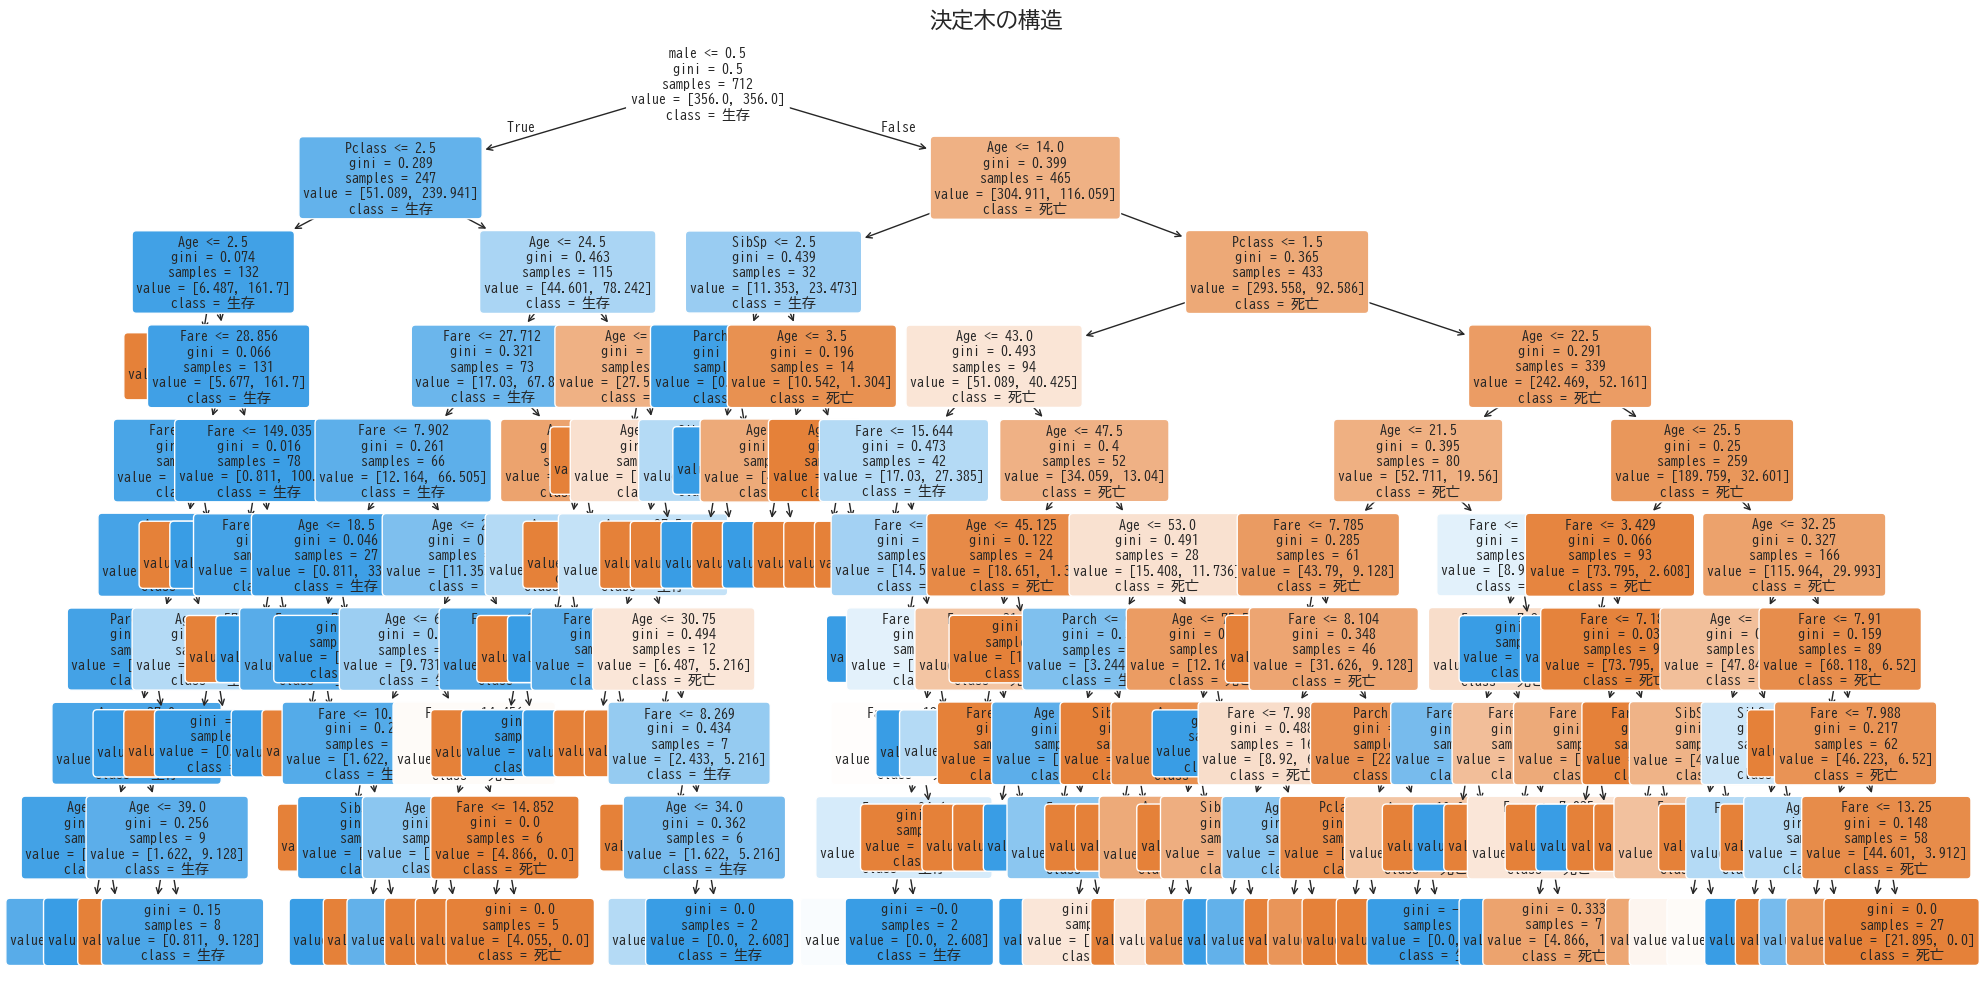

決定木の可視化完了！
   根ノードから見ると、最も重要な判断基準が分かります


In [10]:
# 決定木構造の可視化
from sklearn import tree

plt.figure(figsize=(20, 10))
tree.plot_tree(
    classifier.model,
    feature_names=X.columns,
    class_names=["死亡", "生存"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("決定木の構造", fontsize=16)
plt.tight_layout()
plt.show()

print("決定木の可視化完了！")
print("   根ノードから見ると、最も重要な判断基準が分かります")

## まとめ

### 主な発見

1. **クラス不均衡**: 死亡クラスが生存クラスの約 1.67 倍
2. **重要な特徴量**:
   - `male` (性別) が最も重要 → 「女性と子供を優先」の証拠
   - `Age` (年齢) と `Fare` (運賃) も重要な要素
3. **モデル性能**: 正解率約 88%、AUC スコアも良好

### 次のステップ

- 特徴量エンジニアリング: 交互作用項の追加
- モデルの改善: max_depth の調整、他のアルゴリズムの試行
- 誤分類パターンの詳細分析